### Problem statement
- predict the sentiment of given sentence
- sentiment : positive or negative

In [1]:
!pip install transformers


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Import required packages

In [2]:
import numpy as np
import torch
from transformers import BertTokenizer , BertForSequenceClassification

C:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Select the device

In [3]:
device = ''
if torch.cuda.is_available():
    device = 'cuda'
else:
    device='cpu'

### Get the data

In [4]:
texts = [
"Mind-bending story with amazing visuals.",
"Funny, emotional, and full of life lessons.",
"Beautiful visuals with a deeply emotional story.",
"Dark, intense, and brilliantly acted.",
" Inspiring story with powerful performances.",
"Clever, unpredictable, and socially meaningful.",
"Emotional and deeply touching.",
"Action-packed and emotionally satisfying.",
"Smart thriller with excellent suspense.",
"Powerful story about hope and friendship.",
"Slow-paced and difficult to follow at times.",
"Predictable story with weak character development.",
"Too long and unnecessarily stretched.",
"Some scenes feel forced and unrealistic.",
"Weak ending that feels disappointing.",
"Good concept, but poor execution.",
"Characters lack depth and emotional impact.",
"Too much action with very little story.",
"Dialogues feel unnatural and repetitive.",
"Interesting start, but the movie loses focus."        
]

### decide the labels

In [81]:
labels = [1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0]

### Use tokenizer to tokenize the data

In [82]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

### Load the Model

In [83]:
model = BertForSequenceClassification.from_pretrained("bert-base-uncased")
model = model.to(device)

Loading weights: 100%|█████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 3445.18it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were 

### Train the model on our data

In [96]:
epochs = 10
optimizer = torch.optim.AdamW(model.parameters(),lr=2e-5)

In [97]:
model

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

### Enable the train mode

In [98]:
model.train()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [99]:
losses = []
for epoch in range(epochs):
    total_loss = 0

    for text,label in zip(texts,labels):
        input_tokens = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=32
        )

        input_tokens = {index : token.to(device) for index,token in input_tokens.items()}

        labels_tensor = torch.tensor([label]).to(device)

        optimizer.zero_grad()
        # Splat operator 
        outputs = model(**input_tokens,labels= labels_tensor)
        
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss+=loss.item()
    losses.append(total_loss)

    print(f"epoch : {epoch}, loss : {total_loss}")

epoch : 0, loss : 12.965655446052551
epoch : 1, loss : 16.77378025650978
epoch : 2, loss : 15.47993203997612
epoch : 3, loss : 14.447151780128479
epoch : 4, loss : 15.839609682559967
epoch : 5, loss : 13.616100817918777
epoch : 6, loss : 14.282784581184387
epoch : 7, loss : 13.285022616386414
epoch : 8, loss : 14.099691778421402
epoch : 9, loss : 13.507759690284729


10


Text(0, 0.5, 'Loss')

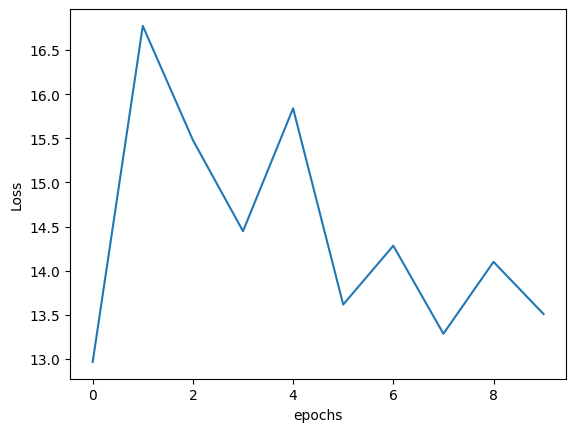

In [148]:
import matplotlib.pyplot as plt
print(len(losses))
plt.plot(losses)
plt.xlabel("epochs")
plt.ylabel("Loss")

### Predict sentiment of a new review

In [141]:
review = "not Interesting start, but the movie is good focus."

In [142]:
input_tokens = tokenizer(
            review,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=32
        )

In [143]:
input_tokens = {index : token.to(device) for index,token in input_tokens.items()}


In [144]:
# Predit sentiment
with torch.no_grad():
    outputs = model(**input_tokens)

In [145]:
outputs.logits

tensor([[ 0.3304, -0.1087]], device='cuda:0')

In [146]:
prediction = torch.argmax(outputs.logits,dim=1).item()
prediction

0

In [147]:
if prediction==1:
    print("Positive")
else:
    print("negetive")

negetive
